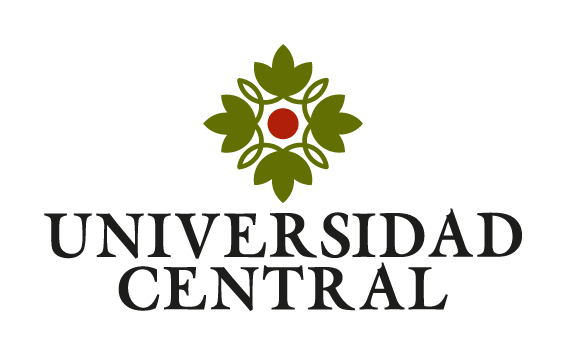

#MAESTRIA EN ANALITICA DE DATOS
---

PROCESAMIENTO DEL LENGUAJE NATURAL

Nombre: Oswaldo Salgado Gómez

Fecha: mayo 16 de 2026

Taller: Trabajo Final

# Etapa 4 (Parte B): Dashboard Jurimétrico — Streamlit


Este notebook construye y lanza la aplicación web del **dashboard jurimétrico** que cierra el prototipo. El dashboard consume los artefactos generados en las etapas anteriores:

- `Retrieval/chroma_db/` → motor de retrieval (Etapa 3)
- `Retrieval/retriever_utils.py` → clase `Retriever`
- `Generacion/respuestas_<timestamp>.json` → respuestas Llama 3 / Mistral (Etapa 4A)
- `Segmentación/corpus_chunks_consolidado.json` → corpus de chunks (para variables estructuradas)

## Vistas del dashboard

1. **Vista General** — métricas del corpus (documentos, chunks, tablas, distribución por documento)
2. **Comparación de Modelos** — respuestas lado a lado de Llama 3 vs Mistral con sus citas
3. **Consulta Interactiva** — el usuario puede plantear preguntas en lenguaje natural, ver fragmentos recuperados con similitud, y elegir filtros
4. **Análisis Jurimétrico** — variables estructuradas extraídas de las tablas (requerimientos por documento, tipos de chunk, conceptos técnicos)

## Arquitectura técnica

- Streamlit no se renderiza nativamente en Colab → se usa `pyngrok` para crear un túnel HTTP público temporal
- La app es **read-only sobre los artefactos**: no re-ejecuta retrieval ni generación pesada, solo lee los JSON ya producidos para que la experiencia sea fluida.
- La sección de consulta interactiva sí ejecuta retrieval en vivo (con el Retriever cargado), pero **no LLM** (eso ya está en el JSON de respuestas)

## Salidas en `Dashboard/`

| Archivo | Contenido |
|---|---|
| `app_dashboard.py` | Aplicación Streamlit completa (autocontenida) |
| `streamlit.log` | Log de ejecución (útil para debug) |

---

## Cómo usar el dashboard

1. **Vista General** → presenta el corpus: en este caso con cinco documentos, N chunks, distribución texto/tabla, parámetros de procesamiento
2. **Comparación de Modelos** → muestra las respuestas Llama 3 vs Mistral lado a lado para una consulta del catálogo
3. **Consulta Interactiva** → recibe una pregunta nueva en vivo y muestra el retrieval
4. **Análisis Jurimétrico** → demuestra el valor de la separación texto/tabla y la trazabilidad estructural
5. **Acerca del Prototipo** → ilustra la arquitectura, consideraciones éticas y limitaciones

## Para retomar el dashboard en otra sesión

Si se cierra Colab y se regresa después, solo se necesita re-ejecutar las celdas 2, 6 y 7 (no es necesario regenerar el `.py` ni reinstalar paquetes si reabres en el mismo runtime).

# HOJA DE RUTA A SEGUIR

0. Montar Google Drive
1. Instalar Dependencias
2. Instalar Librerias
3. Configuración de Rutas
4. Verificar que los Artefactos de las Etapas Previas Existen
5. Generar el Archivo de la Aplicación Streamlit
6. Configurar pyngrok (túnel HTTP público)
7. Lanzar el dashboard
8. Apagar el dashboard (cuando se termine la consulta)
9. Diagnóstico (si algo falla)


#0\. Montar Google Drive

In [ ]:
from google.colab import drive, userdata
drive.mount('/content/drive')

Mounted at /content/drive


# 1\. Instalar Dependencias

**Importante:** después de ejecutar esta celda, **se debe reiniciar el runtime** (Entorno de ejecución → Reiniciar sesión) y luego ejecuta TODO desde la celda 2 en adelante. Esto evita el error `numpy.dtype size changed, may indicate binary incompatibility`.


In [ ]:
!pip install -q "numpy<2.0" "pandas>=2.0,<2.3" \
    streamlit==1.39.0 pyngrok==7.2.0 plotly==5.24.1 \
    chromadb==0.5.5 "transformers>=4.46,<4.50" sentencepiece tqdm \
    "accelerate>=0.34" torch

print('\n' + '=' * 60)
print('⚠ AHORA SE DEBE REINICIAR EL RUNTIME y continuar desde la celda 2')
print('  Menú: Entorno de ejecución → Reiniciar sesión')
print('=' * 60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.3/584.3 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.

#2\. Instalar Librerias

In [ ]:
import os
import json
from google.colab import drive, userdata

#3\. Configuración de Rutas

In [ ]:
BASE_DIR        = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final'
SEGMENT_DIR     = os.path.join(BASE_DIR, 'Segmentación')
RETRIEVAL_DIR   = os.path.join(BASE_DIR, 'Retrieval')
GENERACION_DIR  = os.path.join(BASE_DIR, 'Generacion')
DASHBOARD_DIR   = os.path.join(BASE_DIR, 'Dashboard')
os.makedirs(DASHBOARD_DIR, exist_ok=True)

for ruta, nombre in [(SEGMENT_DIR, 'Segmentación'), (RETRIEVAL_DIR, 'Retrieval'),
                     (GENERACION_DIR, 'Generacion'), (DASHBOARD_DIR, 'Dashboard')]:
    print(f'{nombre:12s} {"✓" if os.path.exists(ruta) else "✗ FALTA"}  {ruta}')

Segmentación ✓  /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación
Retrieval    ✓  /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval
Generacion   ✓  /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Generacion
Dashboard    ✓  /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Dashboard


#4\. Verificar que los Artefactos de las Etapas Previas Existen

In [ ]:
artefactos = {
    'Corpus de chunks (Etapa 2)':
        os.path.join(SEGMENT_DIR, 'corpus_chunks_consolidado.json'),
    'ChromaDB persistente (Etapa 3)':
        os.path.join(RETRIEVAL_DIR, 'chroma_db'),
    'Clase Retriever (Etapa 3)':
        os.path.join(RETRIEVAL_DIR, 'retriever_utils.py'),
    'Respuestas LLM (Etapa 4A)':
        os.path.join(GENERACION_DIR, 'last_respuestas.json'),
}

todo_ok = True
for nombre, ruta in artefactos.items():
    existe = os.path.exists(ruta)
    print(f'{"✓" if existe else "✗"}  {nombre}: {ruta}')
    if not existe:
        todo_ok = False

if todo_ok:
    print('\n✓ Todos los artefactos están listos')
else:
    print('\n⚠ Faltan artefactos. Ejecuta primero las etapas correspondientes.')

✓  Corpus de chunks (Etapa 2): /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/corpus_chunks_consolidado.json
✓  ChromaDB persistente (Etapa 3): /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/chroma_db
✓  Clase Retriever (Etapa 3): /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/retriever_utils.py
✓  Respuestas LLM (Etapa 4A): /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Generacion/last_respuestas.json

✓ Todos los artefactos están listos


#5\. Generar el Archivo de la Aplicación Streamlit

Se escribe toda la app a `Dashboard/app_dashboard.py`. Streamlit la ejecutará desde ese archivo.

In [ ]:
app_code = r'''"""
app_dashboard.py — Dashboard Jurimétrico ANLA
Etapa 4B del prototipo de tesis.
"""
import os
import sys
import json
import glob
from collections import Counter

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import streamlit as st

# -------------------------------------------------------------------------
# Configuración
# -------------------------------------------------------------------------
BASE_DIR        = "/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final"
SEGMENT_DIR     = os.path.join(BASE_DIR, "Segmentación")
RETRIEVAL_DIR   = os.path.join(BASE_DIR, "Retrieval")
CHROMA_DIR      = os.path.join(RETRIEVAL_DIR, "chroma_db")
GENERACION_DIR  = os.path.join(BASE_DIR, "Generacion")

sys.path.append(RETRIEVAL_DIR)

st.set_page_config(
    page_title="Dashboard Jurimétrico ANLA",
    page_icon="⚖️",
    layout="wide",
    initial_sidebar_state="expanded",
)

# -------------------------------------------------------------------------
# Carga de datos (cacheada)
# -------------------------------------------------------------------------
@st.cache_data
def cargar_corpus_chunks():
    ruta = os.path.join(SEGMENT_DIR, "corpus_chunks_consolidado.json")
    with open(ruta, "r", encoding="utf-8") as f:
        return json.load(f)

@st.cache_data
def cargar_respuestas():
    last = os.path.join(GENERACION_DIR, "last_respuestas.json")
    if os.path.exists(last):
        with open(last, "r", encoding="utf-8") as f:
            ruta_actual = json.load(f)["ruta_actual"]
        ruta_full = os.path.join(GENERACION_DIR, ruta_actual)
    else:
        archivos = sorted(glob.glob(os.path.join(GENERACION_DIR, "respuestas_*.json")))
        if not archivos:
            return None
        ruta_full = archivos[-1]
    with open(ruta_full, "r", encoding="utf-8") as f:
        data = json.load(f)
    data["_archivo"] = os.path.basename(ruta_full)
    return data

@st.cache_resource
def cargar_retriever():
    """Carga el Retriever (Longformer + ChromaDB) una sola vez por sesión."""
    from retriever_utils import Retriever
    return Retriever(chroma_dir=CHROMA_DIR)

# -------------------------------------------------------------------------
# Sidebar — navegación
# -------------------------------------------------------------------------
st.sidebar.title("⚖️ Dashboard Jurimétrico")
st.sidebar.markdown("**Autos de Apertura ANLA**")
st.sidebar.markdown("_Sector hidrocarburos_")
st.sidebar.markdown("---")

vista = st.sidebar.radio(
    "Selecciona una vista",
    [
        "📊 Vista General",
        "🤖 Comparación de Modelos",
        "🔍 Consulta Interactiva",
        "📈 Análisis Jurimétrico",
        "ℹ️ Acerca del Prototipo",
    ],
)

st.sidebar.markdown("---")
st.sidebar.markdown(
    "<small>⚠ <b>Advertencia:</b> las respuestas son generadas por IA. "
    "No constituyen asesoría jurídica.</small>",
    unsafe_allow_html=True,
)

# Cargar datos base
corpus = cargar_corpus_chunks()
respuestas_data = cargar_respuestas()
df_chunks = pd.DataFrame(corpus["chunks"])

# =========================================================================
# VISTA 1: VISTA GENERAL
# =========================================================================
if vista == "📊 Vista General":
    st.title("📊 Vista General del Corpus")
    st.markdown(
        "Métricas globales del corpus procesado por las Etapas 1-3 del prototipo."
    )

    # Métricas en columnas
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("📄 Documentos", corpus["total_documentos"])
    c2.metric("🧩 Chunks totales", corpus["total_chunks"])
    c3.metric("📝 Chunks de texto", corpus["chunks_texto"])
    c4.metric("📊 Chunks de tabla", corpus["chunks_tabla"])

    st.markdown("---")

    # Distribución por documento
    col_a, col_b = st.columns(2)
    with col_a:
        st.subheader("Chunks por documento")
        df_por_doc = (
            df_chunks.groupby(["filename", "tipo_chunk"])
            .size().reset_index(name="chunks")
        )
        fig = px.bar(
            df_por_doc, x="filename", y="chunks", color="tipo_chunk",
            barmode="stack",
            color_discrete_map={"texto": "#2E74B5", "tabla": "#E67E22"},
            labels={"filename": "Documento", "chunks": "Cantidad de chunks"},
        )
        fig.update_layout(xaxis_tickangle=-30, height=400)
        st.plotly_chart(fig, use_container_width=True)

    with col_b:
        st.subheader("Distribución de tamaño de chunks (tokens)")
        fig = px.histogram(
            df_chunks, x="n_tokens", color="tipo_chunk", nbins=30,
            color_discrete_map={"texto": "#2E74B5", "tabla": "#E67E22"},
            labels={"n_tokens": "Tokens por chunk", "count": "Frecuencia"},
        )
        fig.update_layout(height=400, barmode="overlay")
        fig.update_traces(opacity=0.7)
        st.plotly_chart(fig, use_container_width=True)

    st.markdown("---")
    st.subheader("Detalle por documento")
    resumen = (
        df_chunks.groupby("filename")
        .agg(
            fecha=("fecha_documento", "first"),
            tipo=("tipo_documento", "first"),
            numero=("numero_documento", "first"),
            chunks=("chunk_id", "count"),
            tokens_promedio=("n_tokens", "mean"),
        )
        .round(0)
        .reset_index()
    )
    st.dataframe(resumen, use_container_width=True, hide_index=True)

    st.subheader("Parámetros de procesamiento")
    params = corpus.get("parametros", {})
    st.json(params)

# =========================================================================
# VISTA 2: COMPARACIÓN DE MODELOS
# =========================================================================
elif vista == "🤖 Comparación de Modelos":
    st.title("🤖 Comparación Llama 3 vs Mistral")

    if respuestas_data is None:
        st.warning(
            "No se encontraron respuestas. Ejecuta primero el notebook "
            "de la Etapa 4A (RAG)."
        )
        st.stop()

    st.caption(f"Archivo cargado: `{respuestas_data['_archivo']}`")
    respuestas = respuestas_data["respuestas"]
    modelos_disponibles = respuestas_data["modelos"]

    # Métricas comparativas
    df_resp = pd.DataFrame([
        {
            "consulta_id": r["consulta_id"], "modelo": r["modelo"],
            "tiempo_retrieval_s": r["tiempo_retrieval_s"],
            "tiempo_generacion_s": r["tiempo_generacion_s"],
            "longitud_chars": len(r["respuesta"]),
            "similitud_top1": (r["chunks_recuperados"][0]["similitud"]
                              if r["chunks_recuperados"] else None),
        }
        for r in respuestas
    ])

    c1, c2 = st.columns(2)
    with c1:
        st.subheader("⏱ Tiempo de generación promedio")
        fig = px.bar(
            df_resp.groupby("modelo")["tiempo_generacion_s"].mean().reset_index(),
            x="modelo", y="tiempo_generacion_s",
            color="modelo", text_auto=".2f",
            labels={"tiempo_generacion_s": "Segundos"},
        )
        fig.update_layout(height=350, showlegend=False)
        st.plotly_chart(fig, use_container_width=True)

    with c2:
        st.subheader("📝 Longitud de respuesta promedio (chars)")
        fig = px.bar(
            df_resp.groupby("modelo")["longitud_chars"].mean().reset_index(),
            x="modelo", y="longitud_chars",
            color="modelo", text_auto=".0f",
            labels={"longitud_chars": "Caracteres"},
        )
        fig.update_layout(height=350, showlegend=False)
        st.plotly_chart(fig, use_container_width=True)

    st.markdown("---")
    st.subheader("📋 Comparación lado a lado por consulta")

    consulta_ids = sorted({r["consulta_id"] for r in respuestas})
    consulta_sel = st.selectbox("Selecciona una consulta", consulta_ids)

    respuestas_consulta = [r for r in respuestas if r["consulta_id"] == consulta_sel]
    if respuestas_consulta:
        st.info(f"**Pregunta:** {respuestas_consulta[0]['query']}")

        cols = st.columns(len(respuestas_consulta))
        for i, r in enumerate(respuestas_consulta):
            with cols[i]:
                st.markdown(f"### {r['modelo']}")
                st.caption(
                    f"⏱ Retrieval: {r['tiempo_retrieval_s']}s | "
                    f"Generación: {r['tiempo_generacion_s']}s"
                )
                st.markdown("**Respuesta:**")
                st.write(r["respuesta"])
                with st.expander(
                    f"📎 Fragmentos recuperados ({len(r['chunks_recuperados'])})"
                ):
                    for j, ch in enumerate(r["chunks_recuperados"], 1):
                        st.markdown(
                            f"**[{j}]** `{ch['tipo_chunk']}` | "
                            f"sim=`{ch['similitud']:.3f}` | "
                            f"doc=`{ch['filename']}` | "
                            f"numeral=`{ch['numeral']}` | "
                            f"pág `{ch['pagina_inicio']}-{ch['pagina_fin']}`"
                        )
                        st.caption(ch["texto_preview"] + "...")

# =========================================================================
# VISTA 3: CONSULTA INTERACTIVA
# =========================================================================
elif vista == "🔍 Consulta Interactiva":
    st.title("🔍 Consulta Interactiva")
    st.markdown(
        "Plantea una pregunta jurídica en lenguaje natural. El motor de "
        "retrieval (ChromaDB + Longformer) devolverá los fragmentos más "
        "relevantes con su similitud coseno y trazabilidad al documento."
    )

    # Filtros
    with st.expander("⚙️ Filtros avanzados", expanded=False):
        c1, c2, c3 = st.columns(3)
        with c1:
            top_k = st.slider("Top-k", 1, 15, 5)
        with c2:
            tipo_chunk_f = st.selectbox(
                "Tipo de chunk", ["(cualquiera)", "texto", "tabla"]
            )
        with c3:
            archivos = ["(cualquiera)"] + sorted(df_chunks["filename"].unique().tolist())
            filename_f = st.selectbox("Documento", archivos)

    query = st.text_input(
        "Escribe tu consulta jurídica:",
        placeholder="Ej. ¿Qué medidas preventivas se contemplan en los autos?",
    )

    if query:
        with st.spinner("Cargando motor de retrieval (primera vez tarda ~30 s)..."):
            retriever = cargar_retriever()

        kwargs = {"top_k": top_k}
        if tipo_chunk_f != "(cualquiera)":
            kwargs["tipo_chunk"] = tipo_chunk_f
        if filename_f != "(cualquiera)":
            kwargs["filename"] = filename_f

        with st.spinner("Recuperando fragmentos..."):
            resultados = retriever.buscar(query, **kwargs)

        if not resultados:
            st.warning("No se encontraron fragmentos con los filtros aplicados.")
        else:
            st.success(f"✓ {len(resultados)} fragmentos recuperados")

            # Gráfico de similitudes
            df_sim = pd.DataFrame([
                {
                    "rank": i + 1,
                    "similitud": r["similitud"],
                    "tipo": r["metadata"]["tipo_chunk"],
                    "doc": r["metadata"]["filename"],
                }
                for i, r in enumerate(resultados)
            ])
            fig = px.bar(
                df_sim, x="rank", y="similitud", color="tipo",
                color_discrete_map={"texto": "#2E74B5", "tabla": "#E67E22"},
                hover_data=["doc"], text_auto=".3f",
                labels={"rank": "Ranking", "similitud": "Similitud coseno"},
            )
            fig.update_layout(height=300)
            st.plotly_chart(fig, use_container_width=True)

            # Fragmentos
            for i, r in enumerate(resultados, 1):
                md = r["metadata"]
                with st.expander(
                    f"**[{i}]** {md['tipo_chunk'].upper()} | "
                    f"sim={r['similitud']:.3f} | "
                    f"{md['filename']} | numeral {md['numeral']} | "
                    f"pág {md['pagina_inicio']}-{md['pagina_fin']}"
                ):
                    if md.get("titulo_bloque"):
                        st.markdown(f"**Título:** {md['titulo_bloque']}")
                    st.write(r["texto"])

                    # Si es tabla, ofrecer ver el bloque padre
                    if md["tipo_chunk"] == "tabla" and md.get("bloque_id_padre"):
                        if st.button(
                            f"📖 Ver contexto (bloque padre)",
                            key=f"padre_{i}",
                        ):
                            padre = retriever.traer_bloque_padre(r)
                            if padre:
                                st.info(
                                    f"**Numeral padre:** {padre['numeral']}\n\n"
                                    f"**Título:** {padre['titulo']}\n\n"
                                    f"{padre['texto_completo'][:2000]}..."
                                )

# =========================================================================
# VISTA 4: ANÁLISIS JURIMÉTRICO
# =========================================================================
elif vista == "📈 Análisis Jurimétrico":
    st.title("📈 Análisis Jurimétrico")
    st.markdown(
        "Variables estructuradas extraídas del corpus para análisis cuantitativo. "
        "Aprovecha la distinción `tipo_chunk='texto'` vs `tipo_chunk='tabla'` "
        "que se introdujo en la Etapa 2."
    )

    df_tablas = df_chunks[df_chunks["tipo_chunk"] == "tabla"].copy()
    df_textos = df_chunks[df_chunks["tipo_chunk"] == "texto"].copy()

    c1, c2, c3 = st.columns(3)
    c1.metric("📊 Tablas indexadas", len(df_tablas))
    c2.metric("📝 Bloques de texto", len(df_textos))
    if len(df_tablas) > 0:
        c3.metric(
            "📏 Tokens promedio (tablas)",
            f"{df_tablas['n_tokens'].mean():.0f}",
        )

    st.markdown("---")

    if len(df_tablas) == 0:
        st.warning("No hay chunks de tabla en el corpus.")
    else:
        st.subheader("Tablas por documento")
        tablas_por_doc = (
            df_tablas.groupby("filename").size().reset_index(name="tablas")
        )
        fig = px.bar(
            tablas_por_doc, x="filename", y="tablas",
            color="tablas", color_continuous_scale="Oranges",
            text_auto=True,
        )
        fig.update_layout(xaxis_tickangle=-30, height=400, showlegend=False)
        st.plotly_chart(fig, use_container_width=True)

        st.markdown("---")
        st.subheader("Dimensiones de las tablas (filas × columnas)")
        if "tabla_dimensiones" in df_tablas.columns:
            df_dim = df_tablas.copy()
            df_dim["filas"] = df_dim["tabla_dimensiones"].apply(
                lambda d: d.get("filas", 0) if isinstance(d, dict) else 0
            )
            df_dim["columnas"] = df_dim["tabla_dimensiones"].apply(
                lambda d: d.get("columnas", 0) if isinstance(d, dict) else 0
            )
            df_dim = df_dim[(df_dim["filas"] > 0) & (df_dim["columnas"] > 0)]
            if len(df_dim) > 0:
                fig = px.scatter(
                    df_dim, x="columnas", y="filas",
                    color="filename", size="n_tokens",
                    hover_data=["numeral", "titulo_bloque"],
                )
                fig.update_layout(height=400)
                st.plotly_chart(fig, use_container_width=True)

        st.markdown("---")
        st.subheader("📑 Explorador de tablas")
        doc_sel = st.selectbox(
            "Documento a explorar",
            sorted(df_tablas["filename"].unique()),
        )
        tablas_doc = df_tablas[df_tablas["filename"] == doc_sel]
        for _, t in tablas_doc.iterrows():
            with st.expander(
                f"Tabla — Numeral {t['numeral']} | pág {t['pagina_inicio']}-{t['pagina_fin']}"
            ):
                if t.get("titulo_bloque"):
                    st.markdown(f"**Contexto:** {t['titulo_bloque']}")
                st.text(t["texto"][:2500])

    st.markdown("---")
    st.subheader("Distribución por tipo de numeral")
    if "tipo_numeral" in df_chunks.columns:
        df_num = (
            df_chunks.groupby("tipo_numeral").size().reset_index(name="chunks")
        )
        df_num = df_num[df_num["tipo_numeral"] != ""]
        if len(df_num) > 0:
            fig = px.pie(df_num, values="chunks", names="tipo_numeral", hole=0.4)
            fig.update_layout(height=400)
            st.plotly_chart(fig, use_container_width=True)

# =========================================================================
# VISTA 5: ACERCA DEL PROTOTIPO
# =========================================================================
else:
    st.title("ℹ️ Acerca del Prototipo")
    st.markdown("""
    ### Arquitectura técnica

    | Etapa | Componente | Tecnología |
    |-------|------------|------------|
    | 1 | Captura y preparación | Parser PDF→JSON |
    | 2 | Segmentación + embeddings | Longformer (4096 tokens), chunks 2048 + overlap 20% |
    | 3 | Retrieval | ChromaDB (coseno) + LangChain + parent-document |
    | 4A | Generación | Llama 3 8B + Mistral 7B (4-bit) |
    | 4B | Dashboard | Streamlit + Plotly |

    ### Consideraciones éticas

    - **Fuentes públicas:** los Autos provienen de la Gaceta Ambiental de la ANLA, repositorio de acceso público.
    - **Presunción de inocencia:** un Auto de Apertura no constituye decisión sancionatoria definitiva.
    - **No automatización de decisión jurídica:** este sistema es una herramienta de apoyo, no sustituye el criterio profesional del abogado.
    - **Trazabilidad:** todas las respuestas incluyen citas al documento, numeral y página de origen.
    - **Mitigación de alucinaciones:** el prompt jurídico obliga al LLM a responder solo con base en el contexto recuperado.

    ### Limitaciones reconocidas

    - Prueba de concepto sobre 5 documentos del sector hidrocarburos
    - Longformer no está especializado en lenguaje jurídico colombiano
    - Evaluación realizada por el autor (single-annotator), sin gold-standard amplio

    ### Autor

    **Oswaldo Salgado Gómez** — Maestría en Analítica de Datos, Universidad Central (2026)
    Director: Profesor Miguel Ángel Rippe Espinosa
    """)
'''

ruta_app = os.path.join(DASHBOARD_DIR, 'app_dashboard.py')
with open(ruta_app, 'w', encoding='utf-8') as f:
    f.write(app_code)

print(f'✓ App generada: {ruta_app}')
print(f'  Líneas: {len(app_code.splitlines())}')

✓ App generada: /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Dashboard/app_dashboard.py
  Líneas: 464


In [ ]:
# 1.1 ¿Streamlit instalado?
!which streamlit
!streamlit --version

# 1.2 ¿El archivo de la app existe?
import os
ruta_app = os.path.join(DASHBOARD_DIR, 'app_dashboard.py')
print(f'\nApp existe: {os.path.exists(ruta_app)}')
print(f'Ruta: {ruta_app}')
print(f'Tamaño: {os.path.getsize(ruta_app)} bytes' if os.path.exists(ruta_app) else 'NO existe')

/usr/local/bin/streamlit
Streamlit, version 1.39.0

App existe: True
Ruta: /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Dashboard/app_dashboard.py
Tamaño: 18413 bytes


In [ ]:
# Limpiar procesos previos
!pkill -f streamlit 2>/dev/null

# Pre-aceptar el prompt de email de Streamlit
streamlit_dir = os.path.expanduser('~/.streamlit')
os.makedirs(streamlit_dir, exist_ok=True)
with open(os.path.join(streamlit_dir, 'credentials.toml'), 'w') as f:
    f.write('[general]\nemail = ""\n')

# Correr Streamlit en foreground por 15 segundos para ver el output real
import subprocess
proc = subprocess.Popen(
    ['streamlit', 'run', ruta_app,
     '--server.port=8501', '--server.headless=true',
     '--server.address=0.0.0.0',
     '--browser.gatherUsageStats=false'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
)

import time
time.sleep(15)
proc.terminate()
output, _ = proc.communicate(timeout=5)
print('--- OUTPUT DE STREAMLIT ---')
print(output)
print('--- FIN ---')

^C
--- OUTPUT DE STREAMLIT ---

  You can now view your Streamlit app in your browser.

  URL: http://0.0.0.0:8501

  Stopping...

--- FIN ---


#6\. Configurar pyngrok (túnel HTTP público)

Streamlit corre en `localhost:8501` dentro del contenedor de Colab, pero ese puerto no es accesible desde fuera. `pyngrok` crea un túnel y te da una URL pública temporal.

**Se necesita un token gratuito de ngrok:**
1. Regístrate gratis en https://ngrok.com/
2. Copiar authtoken de https://dashboard.ngrok.com/get-started/your-authtoken
3. Agrega un secret con nombre `NGROK_AUTH_TOKEN` y valor = tu token
4. Habilitar el toggle de acceso para este notebook

In [ ]:
from pyngrok import ngrok, conf

try:
    NGROK_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
    conf.get_default().auth_token = NGROK_TOKEN
    print('✓ Token de ngrok configurado desde Secrets')
except Exception as e:
    print('⚠ No se encontró NGROK_AUTH_TOKEN en Secrets.')
    print('   Agrega tu token gratuito de https://ngrok.com en el panel de Secrets de Colab.')
    print(f'   Detalle: {e}')

✓ Token de ngrok configurado desde Secrets


#7\. Lanzar el dashboard

Esta celda hace tres cosas:
1. Mata cualquier proceso previo de Streamlit/ngrok (para que sea idempotente)
2. Lanza Streamlit en background sobre el puerto 8501
3. Abre el túnel ngrok y muestra la URL pública

**No se debe detener esta celda mientras se necesite que el dashboard siga vivo.** Para apagarlo, ejecuta la celda 8.

In [ ]:
import subprocess
import socket
import time
import os
from pyngrok import ngrok

# Limpiar procesos previos
!pkill -f streamlit 2>/dev/null
try:
    ngrok.kill()
except Exception:
    pass
time.sleep(3)

# Pre-aceptar el prompt de email de Streamlit
streamlit_dir = os.path.expanduser('~/.streamlit')
os.makedirs(streamlit_dir, exist_ok=True)
with open(os.path.join(streamlit_dir, 'credentials.toml'), 'w') as f:
    f.write('[general]\nemail = ""\n')

# IMPORTANTE: log local en /tmp, NO en Drive (Drive bloquea escrituras en background)
log_file = '/tmp/streamlit.log'
# Limpiar log previo si existe
if os.path.exists(log_file):
    os.remove(log_file)

# Lanzar Streamlit con Popen directamente
print('Lanzando Streamlit...')
proc = subprocess.Popen(
    ['streamlit', 'run', ruta_app,
     '--server.port=8501',
     '--server.headless=true',
     '--server.address=0.0.0.0',
     '--browser.gatherUsageStats=false'],
    stdout=open(log_file, 'w'),
    stderr=subprocess.STDOUT,
    start_new_session=True,   # desacopla del notebook
)
print(f'PID de Streamlit: {proc.pid}')

# Espera activa hasta que Streamlit responda
print('Esperando a que el puerto 8501 abra...')
arrancado = False
for i in range(60):
    time.sleep(1)
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(1)
    try:
        s.connect(('127.0.0.1', 8501))
        s.close()
        print(f'✓ Streamlit responde en el puerto 8501 (tardó {i+1} s)')
        arrancado = True
        break
    except (ConnectionRefusedError, socket.timeout):
        s.close()
        if i % 5 == 4:
            print(f'  ...esperando ({i+1}/60 s) — proceso vivo: {proc.poll() is None}')

if not arrancado:
    print('\n⚠ Streamlit no respondió. Output del log:')
    if os.path.exists(log_file):
        with open(log_file) as f:
            print(f.read())
    print(f'\nProceso vivo: {proc.poll() is None}')
    print(f'Código de salida: {proc.returncode}')
    raise RuntimeError('Streamlit no arrancó.')

# Túnel ngrok
tunnel = ngrok.connect(8501, 'http')
url_publica = tunnel.public_url

print('\n' + '=' * 65)
print('✓ DASHBOARD JURIMÉTRICO ACTIVO')
print('=' * 65)
print(f'\n🌐 URL pública: {url_publica}')
print(f'\n📂 Log:        {log_file}')
print('=' * 65)

^C
Lanzando Streamlit...
PID de Streamlit: 15514
Esperando a que el puerto 8501 abra...
✓ Streamlit responde en el puerto 8501 (tardó 1 s)

✓ DASHBOARD JURIMÉTRICO ACTIVO

🌐 URL pública: https://copper-credibly-heading.ngrok-free.dev

📂 Log:        /tmp/streamlit.log


#8\. Apagar el dashboard (cuando se termine la consulta)

In [ ]:
!pkill -f streamlit 2>/dev/null
try:
    ngrok.kill()
    print('✓ Túnel ngrok cerrado')
except Exception:
    pass
print('✓ Streamlit detenido')

^C
✓ Túnel ngrok cerrado
✓ Streamlit detenido


#9\. Diagnóstico (si algo falla)

Si la URL pública abre con error o el dashboard no carga, se debe revisar el log de Streamlit.

In [ ]:
log_file = os.path.join(DASHBOARD_DIR, 'streamlit.log')
if os.path.exists(log_file):
    print('Últimas 40 líneas del log:')
    !tail -n 40 {log_file}
else:
    print('No existe log todavía. Se debe lanzar primero la celda 6.')

No existe log todavía. Lanza primero la celda 6.
